# Motif distribution across the training & eval datasets

This notebook computes the **distribution of melodic motifs** over the processed
training/eval corpora. It uses the single motif backbone in
[`motif/extract.py`](../motif/extract.py), so the patterns counted here are
exactly the ones used by the data pipeline and the conditioning experiments.

You can choose:

* **Dataset** — `irishman` (`irish*` tunes), `lieder` (`lc*` tunes), or both.
  (`synthetic` motif-crops are also selectable.)
* **Split** — `train`, `eval`, or both.
* **Interval mode** — every abstraction `motif/extract.py` supports:
  `chromatic`, `diatonic`, `step_skip_leap`, `contour`.
* **Motif length** — the window sizes (number of *distinct* successive notes).

Outputs:
1. A summary table (occurrences / unique patterns / top-1 share / entropy) per
   `(dataset, interval_mode, motif length)`.
2. **Motif-length distribution** plots — how occurrence count and pattern
   diversity vary with motif length, per mode and dataset.
3. Top-K motif bar charts and rank–frequency (Zipf) curves for a chosen length.

> Motifs are transposition-invariant, so each tune is read once at its **original
> key**; the distribution is identical regardless of transposition.


In [2]:
# ============================== CONFIG ==============================
# Which processed index bundle to read. BOTH bundles mix lieder (lc*),
# irishman (irish*) and synthetic (synth*) tunes; records are classified
# by filename prefix below, so this only changes HOW MANY irish/synth tunes
# are available (the v1 bundle is smaller; irish50k is the 50k build).
INDEX_BUNDLE = "irish50k"          # "v1"  or  "irish50k"

# Dataset categories to include. Any subset of: "lieder", "irishman", "synthetic".
DATASETS = ["irishman", "lieder"]

# Split(s) to include. Any subset of: "train", "eval".
SPLITS = ["train", "eval"]

# Interval abstraction(s) — every mode supported by motif/extract.py.
INTERVAL_MODES = ["chromatic", "diatonic", "step_skip_leap", "contour"]

# Motif lengths to analyze = number of DISTINCT successive notes per motif.
WINDOW_NOTES = [3, 4, 5, 6, 7, 8]

# Sliding-window stride (1 = start a window at every note position).
STRIDE_NOTES = 1

# Cap on files per (dataset, split) group, for speed. Set to None to use ALL.
# Lieder is small (~1.2k tunes) so it is rarely capped; irishman is large.
MAX_FILES_PER_GROUP = 1500

# Deterministic sampling seed used when MAX_FILES_PER_GROUP applies.
SAMPLE_SEED = 0

# Window length used for the per-pattern detail plots (top-K, Zipf).
DETAIL_WINDOW = 4
# How many top motifs to show in the per-pattern bar charts.
TOP_K = 20

# Directory (relative to this notebook) for CSV/JSON summaries.
OUTPUT_DIR = "results"


In [3]:
# ============================ IMPORTS / BACKBONE ============================
import os, sys, json, glob, random, math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Locate the project root (the dir that contains motif/extract.py) by walking up.
def _find_proj_root(start):
    d = os.path.abspath(start)
    while True:
        if os.path.isfile(os.path.join(d, "motif", "extract.py")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("Could not locate project root (motif/extract.py)")
        d = parent

PROJ_ROOT = _find_proj_root(os.getcwd())
if PROJ_ROOT not in sys.path:
    sys.path.insert(0, PROJ_ROOT)
print("Project root:", PROJ_ROOT)

# Single source of truth for motif extraction.
from motif import extract as ex

# Map the index "key" field (a mode such as Amin / Dmix / Bb) to its written key
# (the folder each transposed .abc lives under) — same mapping the trainer uses.
from abctoolkit.transpose import Key2Mode
MODE2KEY = {mode: key for key, mode_list in Key2Mode.items() for mode in mode_list}

# Index files for each bundle (train / eval jsonl, relative to data/).
DATA_DIR = os.path.join(PROJ_ROOT, "data")
_BUNDLES = {
    "v1": {
        "train": "abcfiles_processed_v1_train.jsonl",
        "eval":  "abcfiles_processed_v1_eval.jsonl",
    },
    "irish50k": {
        "train": "abcfiles_processed_v1_irish50k_train.jsonl",
        "eval":  "abcfiles_processed_v1_irish50k_eval.jsonl",
    },
}

# Classify a record into a dataset category by its filename prefix.
def classify(path):
    base = os.path.basename(path)
    if base.startswith("irish"):
        return "irishman"
    if base.startswith("synth"):
        return "synthetic"
    if base.startswith("lc"):
        return "lieder"
    return "other"

print("Bundle:", INDEX_BUNDLE, "| datasets:", DATASETS, "| splits:", SPLITS)
print("Interval modes:", INTERVAL_MODES, "| window notes:", WINDOW_NOTES)


Project root: /home/users/cy232/Music_Research/AccompGen
Bundle: irish50k | datasets: ['irishman', 'lieder'] | splits: ['train', 'eval']
Interval modes: ['chromatic', 'diatonic', 'step_skip_leap', 'contour'] | window notes: [3, 4, 5, 6, 7, 8]


In [4]:
# ===================== BUILD THE FILE LIST =====================
# For each selected (dataset, split) read its index, classify records, resolve
# each to the .abc file written at the tune's ORIGINAL key, then (optionally)
# subsample to MAX_FILES_PER_GROUP. Motifs are transposition-invariant, so one
# key per tune is enough.

def resolve_abc_path(record):
    """Map an index record {path, key} to the .abc file at its original key.
    Falls back to any available transposition if the original-key file is
    missing (e.g. an extreme key that was skipped during preprocessing)."""
    path = record["path"]
    folder = os.path.dirname(path)
    name = os.path.basename(path)
    key = MODE2KEY.get(record["key"], record["key"])
    f = os.path.join(folder, key, f"{name}_{key}.abc")
    if os.path.exists(f):
        return f
    hits = glob.glob(os.path.join(folder, "*", f"{name}_*.abc"))
    return hits[0] if hits else None

rng = random.Random(SAMPLE_SEED)
# file_list: list of dicts {dataset, split, abc_path}
file_list = []
group_totals = Counter()       # (dataset, split) -> available count (pre-cap)

for split in SPLITS:
    index_path = os.path.join(DATA_DIR, _BUNDLES[INDEX_BUNDLE][split])
    if not os.path.exists(index_path):
        print(f"  [warn] missing index for {split}: {index_path}")
        continue
    # bucket records by dataset
    by_ds = defaultdict(list)
    with open(index_path) as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            ds = classify(rec["path"])
            if ds in DATASETS:
                by_ds[ds].append(rec)
    for ds in DATASETS:
        recs = by_ds.get(ds, [])
        group_totals[(ds, split)] = len(recs)
        if MAX_FILES_PER_GROUP is not None and len(recs) > MAX_FILES_PER_GROUP:
            recs = rng.sample(recs, MAX_FILES_PER_GROUP)
        for rec in recs:
            abc_path = resolve_abc_path(rec)
            if abc_path is not None:
                file_list.append({"dataset": ds, "split": split, "abc_path": abc_path})

print("Available tunes per (dataset, split) before cap:")
for (ds, split), n in sorted(group_totals.items()):
    print(f"  {ds:<10} {split:<6} {n:>7}")
print(f"\nUsing {len(file_list)} files (cap = {MAX_FILES_PER_GROUP} per group).")
used = Counter((f["dataset"], f["split"]) for f in file_list)
for (ds, split), n in sorted(used.items()):
    print(f"  using {ds:<10} {split:<6} {n:>7}")


Available tunes per (dataset, split) before cap:
  irishman   eval      4989
  irishman   train    44903
  lieder     eval       135
  lieder     train     1217

Using 4352 files (cap = 1500 per group).
  using irishman   eval      1500
  using irishman   train     1500
  using lieder     eval       135
  using lieder     train     1217


In [5]:
# ===================== COUNT MOTIFS =====================
# Parse each tune's V:1 melody once, then count motifs for every
# (interval_mode, window_notes) combination.
#
#   counts_combined[mode][w]      -> Counter over ALL selected files
#   counts_by_dataset[ds][mode][w]-> Counter per dataset
#   note_counts[ds]               -> list of melody lengths (notes per tune)

counts_combined = {m: {w: Counter() for w in WINDOW_NOTES} for m in INTERVAL_MODES}
counts_by_dataset = {ds: {m: {w: Counter() for w in WINDOW_NOTES} for m in INTERVAL_MODES}
                     for ds in DATASETS}
note_counts = defaultdict(list)
n_parsed, n_failed = 0, 0

for item in tqdm(file_list, desc="counting motifs"):
    try:
        with open(item["abc_path"], encoding="utf-8") as fh:
            abc = fh.read()
        # key=None -> use the K: field in the file (its original key).
        pitches, note_to_bar, *_ = ex.abc_to_pitches_with_bars(abc, key=None)
    except Exception:
        n_failed += 1
        continue
    if len(pitches) < 2:
        continue
    n_parsed += 1
    note_counts[item["dataset"]].append(len(pitches))
    ds = item["dataset"]
    for mode in INTERVAL_MODES:
        for w in WINDOW_NOTES:
            if len(pitches) < w:
                continue
            c, _ = ex.count_interval_motifs(
                pitches, note_to_bar,
                window_notes=w, stride_notes=STRIDE_NOTES, interval_mode=mode,
            )
            counts_combined[mode][w].update(c)
            counts_by_dataset[ds][mode][w].update(c)

print(f"Parsed {n_parsed} tunes ({n_failed} failed to parse).")


counting motifs:   0%|          | 0/4352 [00:00<?, ?it/s]

Parsed 4352 tunes (0 failed to parse).


In [6]:
# ===================== SUMMARY TABLE =====================
# One row per (scope, interval_mode, motif length). "scope" = combined plus each
# selected dataset. Metrics describe the motif distribution at that setting.

def normalized_entropy(counter):
    """Shannon entropy of the pattern distribution, normalized to [0,1]
    (1 = perfectly uniform over the observed patterns)."""
    total = sum(counter.values())
    if total == 0 or len(counter) <= 1:
        return 0.0
    H = -sum((c / total) * math.log2(c / total) for c in counter.values())
    return H / math.log2(len(counter))

def summarize(counter):
    total = sum(counter.values())
    unique = len(counter)
    top1 = counter.most_common(1)[0][1] if counter else 0
    return {
        "occurrences": total,
        "unique_patterns": unique,
        "top1_share": (top1 / total) if total else 0.0,
        "norm_entropy": normalized_entropy(counter),
    }

scopes = [("combined", counts_combined)] + [(ds, counts_by_dataset[ds]) for ds in DATASETS]
rows = []
for scope, table in scopes:
    for mode in INTERVAL_MODES:
        for w in WINDOW_NOTES:
            s = summarize(table[mode][w])
            rows.append({"scope": scope, "interval_mode": mode, "motif_len": w, **s})

summary_df = pd.DataFrame(rows)
pd.set_option("display.max_rows", 200)
summary_df


,scope,interval_mode,motif_len,occurrences,unique_patterns,top1_share,norm_entropy
0,combined,chromatic,3,431163,1122,0.056728,0.662799
1,combined,chromatic,4,426813,8399,0.020597,0.733751
2,combined,chromatic,5,422463,34403,0.008420,0.804865
3,combined,chromatic,6,418114,84457,0.003987,0.872079
4,combined,chromatic,7,413766,148523,0.001525,0.923955
5,combined,chromatic,8,409419,210848,0.000713,0.958092
6,combined,diatonic,3,431163,532,0.140634,0.596501
7,combined,diatonic,4,426813,3400,0.063698,0.676794
8,combined,diatonic,5,422463,14326,0.027877,0.750838
9,combined,diatonic,6,418114,42190,0.011858,0.819970


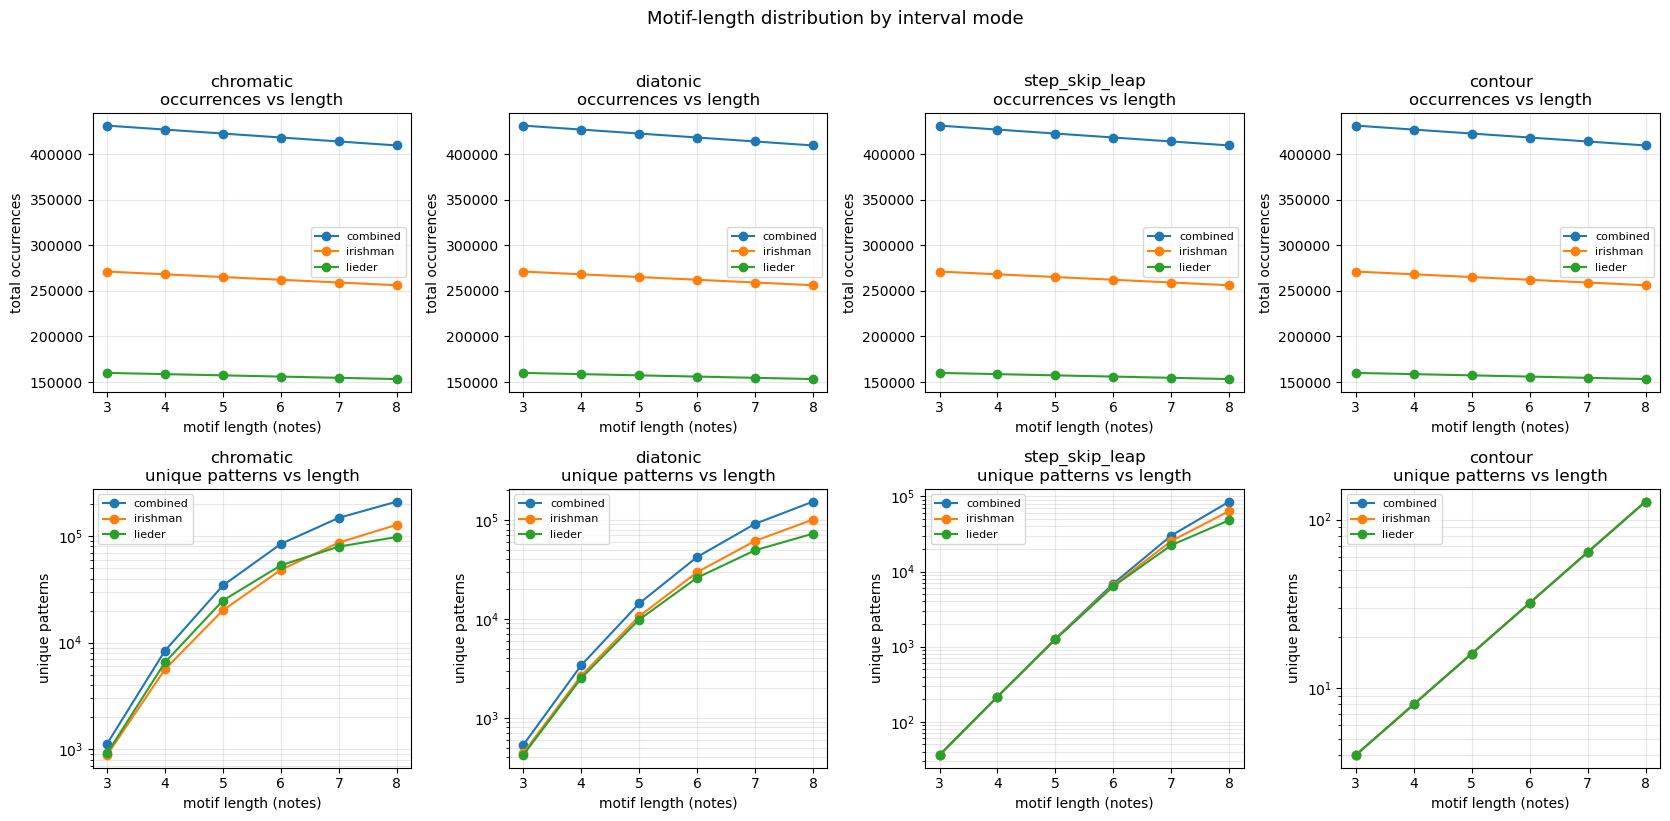

In [7]:
# ===================== MOTIF-LENGTH DISTRIBUTION =====================
# How motif occurrence count and pattern DIVERSITY change with motif length,
# for each interval mode. Shown for the combined corpus and broken out per
# dataset so irishman vs lieder can be compared directly.

plot_scopes = ["combined"] + (list(DATASETS) if len(DATASETS) > 1 else [])

fig, axes = plt.subplots(2, len(INTERVAL_MODES), figsize=(4.2 * len(INTERVAL_MODES), 8),
                         squeeze=False)
for j, mode in enumerate(INTERVAL_MODES):
    ax_occ, ax_uni = axes[0][j], axes[1][j]
    for scope in plot_scopes:
        table = counts_combined if scope == "combined" else counts_by_dataset[scope]
        occ = [sum(table[mode][w].values()) for w in WINDOW_NOTES]
        uni = [len(table[mode][w]) for w in WINDOW_NOTES]
        ax_occ.plot(WINDOW_NOTES, occ, marker="o", label=scope)
        ax_uni.plot(WINDOW_NOTES, uni, marker="o", label=scope)
    ax_occ.set_title(f"{mode}\noccurrences vs length")
    ax_occ.set_xlabel("motif length (notes)"); ax_occ.set_ylabel("total occurrences")
    ax_occ.grid(alpha=0.3); ax_occ.legend(fontsize=8)
    ax_uni.set_title(f"{mode}\nunique patterns vs length")
    ax_uni.set_xlabel("motif length (notes)"); ax_uni.set_ylabel("unique patterns")
    ax_uni.set_yscale("log"); ax_uni.grid(alpha=0.3, which="both"); ax_uni.legend(fontsize=8)
fig.suptitle("Motif-length distribution by interval mode", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


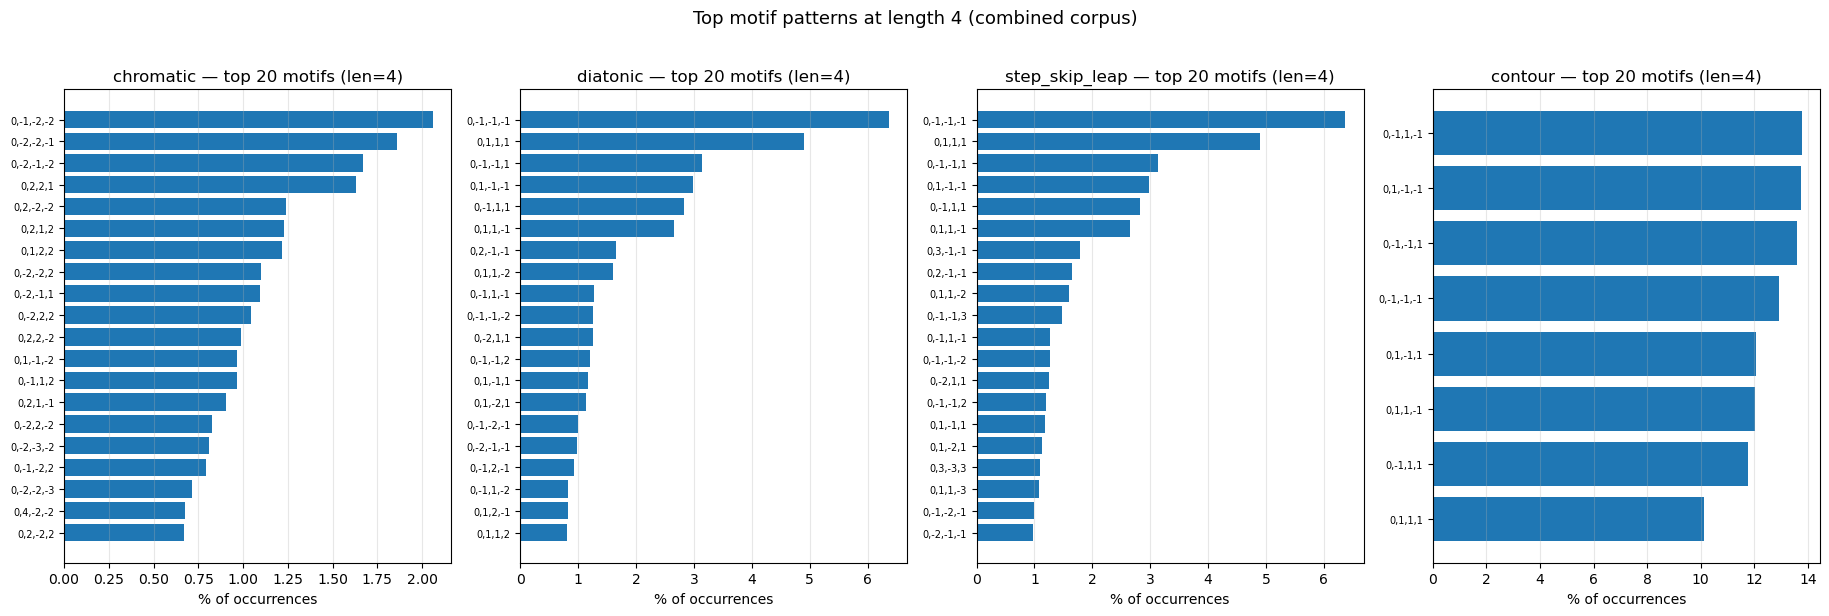

In [8]:
# ===================== TOP-K MOTIFS (per mode, fixed length) =====================
# The most frequent motif patterns at DETAIL_WINDOW notes, per interval mode,
# over the combined corpus. Bars are normalized to % of all occurrences.

w = DETAIL_WINDOW
TOP_K = 20
# w = 5
fig, axes = plt.subplots(1, len(INTERVAL_MODES), figsize=(4.6 * len(INTERVAL_MODES), 6),
                         squeeze=False)
for j, mode in enumerate(INTERVAL_MODES):
    ax = axes[0][j]
    counter = counts_combined[mode][w]
    total = sum(counter.values()) or 1
    top = counter.most_common(TOP_K)
    labels = [",".join(str(x) for x in pat) for pat, _ in top]
    vals = [100.0 * c / total for _, c in top]
    y = range(len(top))
    ax.barh(list(y), vals)
    ax.set_yticks(list(y)); ax.set_yticklabels(labels, fontsize=7)
    ax.invert_yaxis()
    ax.set_title(f"{mode} — top {TOP_K} motifs (len={w})")
    ax.set_xlabel("% of occurrences")
    ax.grid(alpha=0.3, axis="x")
fig.suptitle(f"Top motif patterns at length {w} (combined corpus)", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


In [9]:
INTERVAL_MODES

['chromatic', 'diatonic', 'step_skip_leap', 'contour']

In [10]:
counts_combined["step_skip_leap"][w]

Counter({(0, -1, -1, -1): 27187,
         (0, 1, 1, 1): 20897,
         (0, -1, -1, 1): 13403,
         (0, 1, -1, -1): 12740,
         (0, -1, 1, 1): 12049,
         (0, 1, 1, -1): 11320,
         (0, 3, -1, -1): 7612,
         (0, 2, -1, -1): 7037,
         (0, 1, 1, -2): 6833,
         (0, -1, -1, 3): 6309,
         (0, -1, 1, -1): 5412,
         (0, -1, -1, -2): 5383,
         (0, -2, 1, 1): 5367,
         (0, -1, -1, 2): 5150,
         (0, 1, -1, 1): 5023,
         (0, 1, -2, 1): 4841,
         (0, 3, -3, 3): 4683,
         (0, 1, 1, -3): 4569,
         (0, -1, -2, -1): 4231,
         (0, -2, -1, -1): 4179,
         (0, -3, 1, 1): 4088,
         (0, -1, 3, -1): 4065,
         (0, -1, 2, -1): 3948,
         (0, -3, 3, -3): 3929,
         (0, -1, 1, -2): 3517,
         (0, 1, 2, -1): 3491,
         (0, 1, 1, 2): 3429,
         (0, -3, 3, -1): 3406,
         (0, -2, -1, 1): 3352,
         (0, 1, -1, -2): 3314,
         (0, 3, 1, 1): 3254,
         (0, -1, -2, 2): 3213,
         (0, -

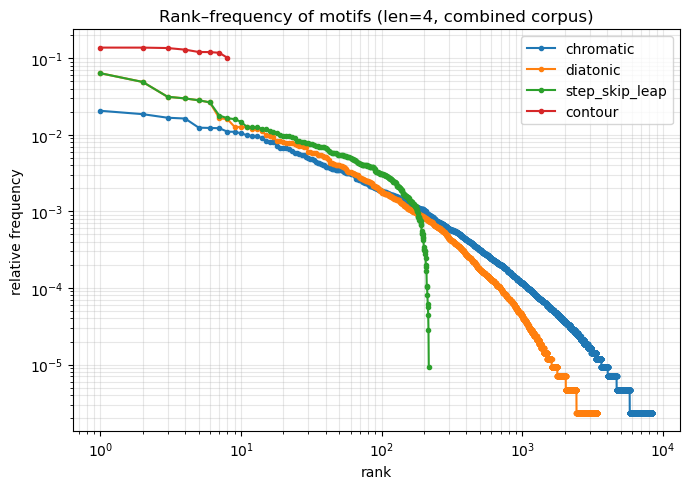

In [11]:
# ===================== RANK–FREQUENCY (ZIPF) =====================
# Log-log rank vs frequency for each interval mode at DETAIL_WINDOW notes — how
# concentrated the motif vocabulary is (steeper = a few motifs dominate).

w = DETAIL_WINDOW
fig, ax = plt.subplots(figsize=(7, 5))
for mode in INTERVAL_MODES:
    counter = counts_combined[mode][w]
    total = sum(counter.values()) or 1
    freqs = sorted((c / total for c in counter.values()), reverse=True)
    ax.loglog(range(1, len(freqs) + 1), freqs, marker=".", linestyle="-", label=mode)
ax.set_xlabel("rank"); ax.set_ylabel("relative frequency")
ax.set_title(f"Rank–frequency of motifs (len={w}, combined corpus)")
ax.grid(alpha=0.3, which="both"); ax.legend()
fig.tight_layout()
plt.show()


In [12]:
# ===================== SAVE RESULTS =====================
# CSV of the summary table, plus a JSON of the full pattern counts (patterns
# rendered as comma-joined strings) for downstream analysis.

out_dir = os.path.join(os.getcwd(), OUTPUT_DIR)
os.makedirs(out_dir, exist_ok=True)
tag = f"{INDEX_BUNDLE}_{'-'.join(DATASETS)}_{'-'.join(SPLITS)}"

summary_path = os.path.join(out_dir, f"motif_summary_{tag}.csv")
summary_df.to_csv(summary_path, index=False)

def counter_to_jsonable(table):
    return {mode: {str(w): {",".join(map(str, pat)): c
                            for pat, c in table[mode][w].most_common()}
                   for w in WINDOW_NOTES}
            for mode in INTERVAL_MODES}

full = {
    "config": {
        "index_bundle": INDEX_BUNDLE, "datasets": DATASETS, "splits": SPLITS,
        "interval_modes": INTERVAL_MODES, "window_notes": WINDOW_NOTES,
        "stride_notes": STRIDE_NOTES, "max_files_per_group": MAX_FILES_PER_GROUP,
        "n_files_used": len(file_list),
    },
    "combined": counter_to_jsonable(counts_combined),
    "by_dataset": {ds: counter_to_jsonable(counts_by_dataset[ds]) for ds in DATASETS},
}
counts_path = os.path.join(out_dir, f"motif_counts_{tag}.json")
with open(counts_path, "w") as fh:
    json.dump(full, fh, indent=2)

print("Saved:")
print(" ", summary_path)
print(" ", counts_path)


Saved:
  /home/users/cy232/Music_Research/AccompGen/exploratory/results/motif_summary_irish50k_irishman-lieder_train-eval.csv
  /home/users/cy232/Music_Research/AccompGen/exploratory/results/motif_counts_irish50k_irishman-lieder_train-eval.json
